In [1]:
from hci import lib
import ctypes
import numpy as np
import math
import pyscf
from pyscf import gto, scf

libhci = lib.libhci
rng = np.random.default_rng()

# Ranking and indexing

In [2]:
norb = 8
nocc = 4
combs = np.empty(min(nocc, norb-nocc)+1, dtype=np.uint64)
inverted = libhci.get_consecutive_combs(combs.ctypes.data_as(ctypes.c_void_p), 
                 ctypes.c_size_t(norb),
                 ctypes.c_size_t(nocc))
print(inverted, combs)

0 [ 1  8 28 56 70]


In [3]:
norb = 8
nocc = 4
rank_table = np.empty((nocc, norb-nocc+1), dtype=np.uint64, order='C')
libhci.get_rank_table(rank_table.ctypes.data_as(ctypes.c_void_p),
                                       ctypes.c_size_t(norb),
                                       ctypes.c_size_t(nocc))
print(rank_table)

[[ 0  1  2  3  4]
 [ 0  1  3  6 10]
 [ 0  1  4 10 20]
 [ 0  1  5 15 35]]


In [4]:
rank = 0
index = libhci.find_row_index(ctypes.c_uint64(rank),
                              rank_table[2][:].ctypes.data_as(ctypes.c_void_p),
                              ctypes.c_size_t(norb),
                              ctypes.c_size_t(nocc))
print(index)

0


In [5]:
import itertools
norb = 8
nocc = 4
# occ_list = np.array([1,3,4,5], dtype=np.int32)
for comb in itertools.combinations(np.arange(norb, dtype=np.uintp), nocc):
    occ_list = np.array(comb)
    rank = libhci.rank(occ_list.ctypes.data_as(ctypes.c_void_p),
                       rank_table.ctypes.data_as(ctypes.c_void_p),
                       ctypes.c_size_t(norb),
                       ctypes.c_size_t(nocc))
    print(occ_list, rank)

[0 1 2 3] 0
[0 1 2 4] 1
[0 1 2 5] 5
[0 1 2 6] 15
[0 1 2 7] 35
[0 1 3 4] 2
[0 1 3 5] 6
[0 1 3 6] 16
[0 1 3 7] 36
[0 1 4 5] 9
[0 1 4 6] 19
[0 1 4 7] 39
[0 1 5 6] 25
[0 1 5 7] 45
[0 1 6 7] 55
[0 2 3 4] 3
[0 2 3 5] 7
[0 2 3 6] 17
[0 2 3 7] 37
[0 2 4 5] 10
[0 2 4 6] 20
[0 2 4 7] 40
[0 2 5 6] 26
[0 2 5 7] 46
[0 2 6 7] 56
[0 3 4 5] 12
[0 3 4 6] 22
[0 3 4 7] 42
[0 3 5 6] 28
[0 3 5 7] 48
[0 3 6 7] 58
[0 4 5 6] 31
[0 4 5 7] 51
[0 4 6 7] 61
[0 5 6 7] 65
[1 2 3 4] 4
[1 2 3 5] 8
[1 2 3 6] 18
[1 2 3 7] 38
[1 2 4 5] 11
[1 2 4 6] 21
[1 2 4 7] 41
[1 2 5 6] 27
[1 2 5 7] 47
[1 2 6 7] 57
[1 3 4 5] 13
[1 3 4 6] 23
[1 3 4 7] 43
[1 3 5 6] 29
[1 3 5 7] 49
[1 3 6 7] 59
[1 4 5 6] 32
[1 4 5 7] 52
[1 4 6 7] 62
[1 5 6 7] 66
[2 3 4 5] 14
[2 3 4 6] 24
[2 3 4 7] 44
[2 3 5 6] 30
[2 3 5 7] 50
[2 3 6 7] 60
[2 4 5 6] 33
[2 4 5 7] 53
[2 4 6 7] 63
[2 5 6 7] 67
[3 4 5 6] 34
[3 4 5 7] 54
[3 4 6 7] 64
[3 5 6 7] 68
[4 5 6 7] 69


In [6]:
norb = 8
nocc = 4

rank_table = np.empty((nocc, norb-nocc+1), dtype=np.uint64)
libhci.get_rank_table(rank_table.ctypes.data_as(ctypes.c_void_p),
                                       ctypes.c_size_t(norb),
                                       ctypes.c_size_t(nocc))
print(rank_table)

rank = 57
occ_list = np.zeros(nocc, dtype=np.uintp)
libhci.unrank(ctypes.c_uint64(rank),
              occ_list.ctypes.data_as(ctypes.c_void_p),
              rank_table.ctypes.data_as(ctypes.c_void_p),
              ctypes.c_size_t(norb),
              ctypes.c_size_t(nocc))
print(occ_list)

[[ 0  1  2  3  4]
 [ 0  1  3  6 10]
 [ 0  1  4 10 20]
 [ 0  1  5 15 35]]
[1 2 6 7]


# Double excitation storage

In [7]:
from hci import lib
import numpy as np
libhci = lib.libhci
rng = np.random.default_rng()

norb = 10
na = 5
nb = 3
config_table_a, config_table_a_complement, config_table_b, config_table_b_complement, exc_table_4o, exc_table_2o = lib.get_ranking_tables(norb, (na, nb))

print(config_table_a)
print(config_table_b)
print(exc_table_4o)
print(exc_table_2o)

nij = norb*(norb+1)//2
mock_eri_s8 = rng.random(nij*(nij+1)//2)
mock_eri_s4 = rng.random(nij**2)

doubles_aa = lib.get_stored_double_exc(mock_eri_s8, exc_table_4o, norb)
max_mag_aa = lib.get_max_magnitudes(doubles_aa, norb)
doubles_aa = doubles_aa[np.argsort(max_mag_aa)[::-1]]

doubles_bb = lib.get_stored_double_exc(mock_eri_s8, exc_table_4o, norb)
max_mag_bb = lib.get_max_magnitudes(doubles_bb, norb)
doubles_bb = doubles_bb[np.argsort(max_mag_bb)[::-1]]

mixed_ab = lib.get_stored_mixed_exc(mock_eri_s4, exc_table_2o, norb)
max_mag_ab = np.abs(mixed_ab['ijkl'])
mixed_ab = mixed_ab[np.argsort(max_mag_ab)[::-1]]

print(doubles_aa)
print(doubles_bb)
print(mixed_ab)

[[  0   1   2   3   4   5]
 [  0   1   3   6  10  15]
 [  0   1   4  10  20  35]
 [  0   1   5  15  35  70]
 [  0   1   6  21  56 126]]
[[ 0  1  2  3  4  5  6  7]
 [ 0  1  3  6 10 15 21 28]
 [ 0  1  4 10 20 35 56 84]]
[[  0   1   2   3   4   5   6]
 [  0   1   3   6  10  15  21]
 [  0   1   4  10  20  35  56]
 [  0   1   5  15  35  70 126]]
[[ 0  1  2  3  4  5  6  7  8]
 [ 0  1  3  6 10 15 21 28 36]]
[( 98,  8.55829872e-01, -9.74832010e-01)
 (167, -4.70402555e-01,  9.70012479e-01)
 ( 66,  7.41450785e-01,  2.25321793e-01)
 (151, -9.54316986e-01,  7.69864028e-01)
 ( 37, -9.43568507e-01,  6.26954639e-01)
 ( 59, -9.42964983e-01,  7.23474241e-01)
 ( 77, -7.78734407e-01, -1.62259835e-01)
 (133, -8.95609545e-01, -2.86380374e-02)
 (121,  1.56304786e-01, -9.23499099e-01)
 (198, -9.07248356e-01,  5.31167605e-01)
 (176, -2.74700644e-01,  8.98689512e-01)
 (132, -7.10484764e-01, -1.72498949e-01)
 (166,  2.63248870e-01, -8.77140666e-01)
 (150,  8.66682235e-01, -4.09019803e-01)
 (193, -8.56965618e-01

In [8]:
magnitudes = np.empty(math.comb(norb, 4), dtype=np.double)
libhci.get_max_magnitudes(doubles_aa.ctypes.data_as(ctypes.c_void_p),
                          magnitudes.ctypes.data_as(ctypes.c_void_p),
                          ctypes.c_size_t(math.comb(norb,4)))
print(magnitudes)

[0.97483201 0.97001248 0.96677258 0.95431699 0.94356851 0.94296498
 0.94099424 0.92424758 0.9234991  0.90724836 0.89868951 0.88298371
 0.87714067 0.86668223 0.85696562 0.83690209 0.83670105 0.83258929
 0.82602809 0.81250029 0.8089202  0.80291061 0.80234999 0.78848554
 0.78535344 0.78385331 0.78001923 0.77999464 0.77638072 0.75453112
 0.75277491 0.75219859 0.74187778 0.7333558  0.71870929 0.71800659
 0.71403627 0.71342557 0.71081121 0.71026606 0.70042549 0.69909053
 0.69248749 0.69208046 0.67813124 0.67627131 0.67282558 0.67267833
 0.67190167 0.66784229 0.66239239 0.65905889 0.65854581 0.65782755
 0.64721369 0.64463631 0.64262427 0.6390356  0.63762448 0.63560895
 0.63220615 0.63201136 0.63183032 0.627186   0.61977847 0.61829717
 0.61645946 0.61619568 0.61449128 0.61283197 0.60800566 0.60727451
 0.60027811 0.59931519 0.5980404  0.59749278 0.59620487 0.59614643
 0.58066151 0.58041111 0.57998926 0.5721305  0.57024393 0.56929826
 0.56374723 0.5622496  0.56206219 0.56138435 0.55787681 0.5563

In [9]:
print(magnitudes-(doubles_aa['ijkl']+doubles_aa['iljk']))

[1.09383415e+00 4.70402555e-01 0.00000000e+00 1.13876994e+00
 1.26018237e+00 1.16245573e+00 1.88198848e+00 1.84849516e+00
 1.69069341e+00 1.28332911e+00 2.74700644e-01 1.76596743e+00
 1.49103246e+00 4.09019803e-01 1.55050822e+00 7.51040390e-01
 1.67340210e+00 1.18832267e+00 2.85144749e-02 4.47791172e-01
 1.27316003e+00 1.60582122e+00 1.52179811e+00 0.00000000e+00
 1.44113885e-03 0.00000000e+00 1.25276554e+00 2.16379331e-01
 1.55276144e+00 5.04853414e-01 1.45848582e+00 1.06428416e-01
 1.15053978e-01 1.22802890e+00 1.43741859e+00 1.14873654e+00
 1.42807254e+00 1.26010292e+00 3.84121574e-01 1.42053212e+00
 1.40085098e+00 1.24472974e+00 1.23388575e+00 1.50640443e-01
 3.30478708e-01 4.42912520e-01 1.18846765e+00 0.00000000e+00
 1.25651511e+00 9.51365159e-01 5.07876182e-01 0.00000000e+00
 1.31709163e+00 1.31565509e+00 9.64288507e-01 8.85916160e-01
 0.00000000e+00 0.00000000e+00 1.27524896e+00 1.19604415e+00
 4.46629548e-01 2.74540136e-02 0.00000000e+00 1.24976764e+00
 1.13825218e+00 5.064868

# Subspace enlargement

## H2 - mixed only

In [10]:
import hci.hci_uhf
from pyscf import gto, scf
from pyscf.fci.direct_spin1 import _unpack_nelec
import numpy as np

In [11]:
mol = gto.M(
    atom = '''
H    -0.340000    0.000000    0.000000
H    0.340000    0.000000    0.000000''',
    basis = '3-21g',
    charge = 0,
    spin = 0  # = 2S = spin_up - spin_down
)

In [12]:
mf = scf.UHF(mol)
mf.kernel()

converged SCF energy = -1.12046039838593  <S^2> = 1.110223e-15  2S+1 = 1


np.float64(-1.1204603983859307)

In [13]:
mf.scf_summary

{'nuc': np.float64(0.7782017807647059),
 'e1': np.float64(-2.573679301158442),
 'e2': np.float64(0.6750171220078054)}

In [14]:
nelec = _unpack_nelec(mol.nelectron, mol.spin)
nao = mol.nao_nr()
mo = mf.mo_coeff
norb = mo.shape[1]
hcore = mf.get_hcore()
eri_ao = mf._eri
print(norb, nelec)
print(mo)

4 (1, 1)
[[[ 0.29920008  0.10240537  0.75808043 -1.12464738]
  [ 0.29744806  1.77543079 -0.65876995  1.31493919]
  [ 0.29920008 -0.10240537  0.75808043  1.12464738]
  [ 0.29744806 -1.77543079 -0.65876995 -1.31493919]]

 [[ 0.2992001   0.10240537  0.75808042  1.12464738]
  [ 0.29744805  1.77543078 -0.65876996 -1.3149392 ]
  [ 0.2992001  -0.10240537  0.75808042 -1.12464738]
  [ 0.29744805 -1.77543078 -0.65876996  1.3149392 ]]]


In [15]:
hci.hci_uhf.kernel(hcore, eri_ao, mo, norb, nelec, 0.0)

[[3 3]
 [2 2]
 [1 1]
 [1 3]
 [3 1]
 [3 2]
 [1 2]
 [2 3]
 [2 1]]
[[1 0]
 [2 0]
 [3 0]
 [0 1]
 [0 2]
 [0 3]]



## Water - all types

In [16]:
import hci.hci_uhf
from pyscf import gto, scf, ao2mo
from pyscf.fci.direct_spin1 import _unpack_nelec
import numpy as np
import ctypes
from functools import reduce
import math

In [17]:
mol = gto.M(
    atom = '''
O        0.000000    0.000000    0.117790
H        0.000000    0.755453   -0.471161
H        0.000000   -0.755453   -0.471161''',
    basis = 'sto-3g',
    charge = 1,
    spin = 1  # = 2S = spin_up - spin_down
)

In [18]:
mf = scf.UHF(mol)
mf.kernel()

converged SCF energy = -74.6557767322148  <S^2> = 0.75520546  2S+1 = 2.0051987


np.float64(-74.65577673221476)

In [19]:
mf.scf_summary

{'nuc': np.float64(9.189193229309746),
 'e1': np.float64(-116.41508892506982),
 'e2': np.float64(32.57011896354531)}

In [20]:
nelec = _unpack_nelec(mol.nelectron, mol.spin)
nao = mol.nao_nr()
mo = mf.mo_coeff
norb = mo.shape[1]
hcore = mf.get_hcore()
eri_ao = mf._eri
print(norb, nelec)

7 (5, 4)


In [21]:
hci.hci_uhf.kernel(hcore, eri_ao, mo, norb, nelec, 0.02)

[[18  0]
 [ 0 28]
 [ 8 16]
 [ 4  7]
 [ 8  7]
 [ 4 16]
 [ 1 16]
 [ 3  6]
 [ 8  5]
 [ 1  7]
 [ 6 15]
 [ 1  5]
 [ 2  3]
 [ 4  5]
 [ 9 17]
 [ 6  6]
 [ 3 17]
 [ 3 15]
 [ 9  6]
 [ 5  8]
 [ 7  2]]
[]



In [22]:
config_table_a, config_table_a_complement, config_table_b, config_table_b_complement, exc_table_4o, exc_table_2o = hci.lib.get_ranking_tables(7, (5, 4))

In [23]:
a_rank = 18
b_rank = 0
occ_a = np.empty(5, dtype=np.uint64)
occ_b = np.empty(4, dtype=np.uint64)
hci.lib.libhci.unrank(ctypes.c_uint64(a_rank), 
                      occ_a.ctypes.data_as(ctypes.c_void_p),
                      config_table_a.ctypes.data_as(ctypes.c_void_p),
                      ctypes.c_size_t(7),
                      ctypes.c_size_t(5))
hci.lib.libhci.unrank(ctypes.c_uint64(b_rank), 
                      occ_b.ctypes.data_as(ctypes.c_void_p),
                      config_table_b.ctypes.data_as(ctypes.c_void_p),
                      ctypes.c_size_t(7),
                      ctypes.c_size_t(4))
print(occ_a, occ_b)

[0 3 4 5 6] [0 1 2 3]


In [24]:
exc_rank_aa = 27
exc_aa = np.empty(4, dtype=np.uint64)
hci.lib.libhci.unrank(ctypes.c_uint64(exc_rank_aa), 
                      exc_aa.ctypes.data_as(ctypes.c_void_p),
                      exc_table_4o.ctypes.data_as(ctypes.c_void_p),
                      ctypes.c_size_t(7),
                      ctypes.c_size_t(4))
print(exc_aa)

[1 2 5 6]


In [25]:
exc_rank_bb = 0
exc_bb = np.empty(4, dtype=np.uint64)
hci.lib.libhci.unrank(ctypes.c_uint64(exc_rank_bb), 
                      exc_bb.ctypes.data_as(ctypes.c_void_p),
                      exc_table_4o.ctypes.data_as(ctypes.c_void_p),
                      ctypes.c_size_t(7),
                      ctypes.c_size_t(4))
print(exc_bb)

[0 1 2 3]


In [26]:
mo_a, mo_b = mo
nelec_a, nelec_b = nelec
h1e_aa = reduce(np.dot, (mo_a.conj().T, hcore, mo_a))
h1e_bb = reduce(np.dot, (mo_b.conj().T, hcore, mo_b))
eri_mo_aaaa_s1 = ao2mo.restore('s1', ao2mo.full(eri_ao, mo_a), norb)
eri_mo_bbbb_s1 = ao2mo.restore('s1', ao2mo.full(eri_ao, mo_b), norb)
eri_mo_aabb_s1 = ao2mo.restore('s1', ao2mo.general(eri_ao, [mo_a, mo_a, mo_b, mo_b]), norb)

In [27]:
def index_2d(i, j):
    if i>j:
        return math.comb(i+1, 2)+j
    else:
        return math.comb(j+1, 2)+i

def index_4d(i, j, k, l):
    return index_2d(index_2d(i, j), index_2d(k, l))

In [28]:
eri_mo_aaaa_s8 = ao2mo.restore('s8', ao2mo.full(eri_ao, mo_a), norb)
i = 1
j = 2
k = 5
l = 6
print(eri_mo_aaaa_s1[i,j,k,l]-eri_mo_aaaa_s1[i,l,k,j])
print(eri_mo_aaaa_s8[index_4d(i,j,k,l)]-eri_mo_aaaa_s8[index_4d(i,l,k,j)])

0.06755658843298327
0.06755658843298329


## Full testing script

In [29]:
import hci.hci_uhf
from pyscf import gto, scf, ao2mo
from pyscf.fci.direct_spin1 import _unpack_nelec
import numpy as np
import ctypes
from functools import reduce
import math

In [30]:
mol = gto.M(
    atom = '''
O        0.000000    0.000000    0.117790
H        0.000000    0.755453   -0.471161
H        0.000000   -0.755453   -0.471161''',
    basis = 'sto-3g',
    charge = 1,
    spin = 1  # = 2S = spin_up - spin_down
)

In [31]:
mf = scf.UHF(mol)
mf.kernel()

converged SCF energy = -74.6557767322147  <S^2> = 0.75520546  2S+1 = 2.0051987


np.float64(-74.65577673221473)

In [32]:
mf.scf_summary

{'nuc': np.float64(9.189193229309746),
 'e1': np.float64(-116.41508892506978),
 'e2': np.float64(32.5701189635453)}

In [33]:
nelec = _unpack_nelec(mol.nelectron, mol.spin)
nao = mol.nao_nr()
mo = mf.mo_coeff
norb = mo.shape[1]
hcore = mf.get_hcore()
eri_ao = mf._eri
print(norb, nelec)

7 (5, 4)


In [34]:
mo_a, mo_b = mo
nelec_a, nelec_b = nelec
h1e_aa = reduce(np.dot, (mo_a.conj().T, hcore, mo_a))
h1e_bb = reduce(np.dot, (mo_b.conj().T, hcore, mo_b))
eri_mo_aaaa = ao2mo.restore('s8', ao2mo.full(eri_ao, mo_a), norb)
eri_mo_bbbb = ao2mo.restore('s8', ao2mo.full(eri_ao, mo_b), norb)
eri_mo_aabb = ao2mo.restore('s4', ao2mo.general(eri_ao, [mo_a, mo_a, mo_b, mo_b]), norb)

In [35]:
config_table_a, config_table_a_complement, config_table_b, config_table_b_complement, exc_table_4o, exc_table_2o = hci.lib.get_ranking_tables(norb, nelec)

In [36]:
doubles_aa = hci.lib.get_stored_double_exc(eri_mo_aaaa, exc_table_4o, norb)

In [37]:
print(doubles_aa)

[( 0,  3.21667135e-17,  4.35582971e-19)
 ( 1, -4.92703941e-18, -1.33052712e-18)
 ( 2, -5.75629915e-18,  9.80711344e-19)
 ( 3, -9.95116558e-18,  1.01609027e-17)
 ( 4,  6.03774782e-18, -4.23593853e-18)
 ( 5, -1.79635793e-16,  4.52745744e-17)
 ( 6, -1.73797436e-17,  1.03399220e-18)
 ( 7, -2.67005090e-17,  2.70324602e-17)
 ( 8, -2.67962135e-17,  3.02042982e-17)
 ( 9,  2.03187800e-02, -1.17654898e-03)
 (10,  3.08217427e-17,  1.73074304e-17)
 (11,  1.98779899e-16, -1.72979100e-16)
 (12, -2.12490151e-20,  2.43947670e-18)
 (13,  6.59009449e-18, -1.76896411e-18)
 (14,  6.32678621e-17,  5.69660491e-20)
 (15, -3.13597976e-02,  8.63432154e-03)
 (16, -4.92308928e-17,  1.51113569e-17)
 (17, -9.33795885e-19, -2.60223828e-18)
 (18, -1.19270909e-17,  2.02153688e-17)
 (19, -1.24313283e-16,  8.34556678e-18)
 (20,  4.15750321e-03,  3.11445775e-03)
 (21,  3.57162742e-02, -3.32249047e-02)
 (22,  7.27625376e-18,  3.88525929e-18)
 (23,  6.25088332e-17, -5.65041863e-17)
 (24, -9.40888332e-18,  8.03389217e-18)


In [38]:
doubles_aa = hci.lib.get_stored_double_exc(eri_mo_aaaa, exc_table_4o, norb)
max_mag_aa = hci.lib.get_max_magnitudes(doubles_aa, norb)
sorted_indices = np.argsort(max_mag_aa)[::-1]
doubles_aa = doubles_aa[sorted_indices]
max_mag_aa = max_mag_aa[sorted_indices]

doubles_bb = hci.lib.get_stored_double_exc(eri_mo_bbbb, exc_table_4o, norb)
max_mag_bb = hci.lib.get_max_magnitudes(doubles_bb, norb)
sorted_indices = np.argsort(max_mag_bb)[::-1]
doubles_bb = doubles_bb[sorted_indices]
max_mag_bb = max_mag_bb[sorted_indices]

mixed_ab = hci.lib.get_stored_mixed_exc(eri_mo_aabb, exc_table_2o, norb)
max_mag_ab = np.abs(mixed_ab['ijkl'])
sorted_indices = np.argsort(max_mag_ab)[::-1]
mixed_ab = mixed_ab[sorted_indices]
max_mag_ab = max_mag_ab[sorted_indices]

In [39]:
ranks = np.array([[0, 0]], dtype=np.uint64)
coeffs = np.array([1.0], dtype=np.double)

### Double excitations

In [40]:
add_thresh = 0.01
add_list, nadd = hci.lib.enlarge_space_doubles(ranks, coeffs, norb, nelec_a, nelec_b, add_thresh, 
                                               config_table_a, config_table_b, exc_table_4o, exc_table_2o, 
                                               doubles_aa, doubles_bb, mixed_ab,
                                               max_mag_aa, max_mag_bb, max_mag_ab)

In [41]:
a_occ = np.zeros(nelec_a, dtype=np.uint64)
b_occ = np.zeros(nelec_b, dtype=np.uint64)
hci.lib.unrank(0, a_occ, config_table_a, norb, nelec_a)
hci.lib.unrank(0, b_occ, config_table_b, norb, nelec_b)
ci0_astr = set(a_occ)
ci0_bstr = set(b_occ)
eri_mo_aaaa_s1 = ao2mo.restore('s1', eri_mo_aaaa, norb)
eri_mo_bbbb_s1 = ao2mo.restore('s1', eri_mo_bbbb, norb)
eri_mo_aabb_s1 = ao2mo.restore('s1', eri_mo_aabb, norb)
for entry in add_list[:nadd]:
    arank = entry[0]
    brank = entry[1]
    print(arank, brank)
    hci.lib.unrank(arank, a_occ, config_table_a, norb, nelec_a)
    hci.lib.unrank(brank, b_occ, config_table_b, norb, nelec_b)
    print(a_occ, b_occ)
    excdet_astr = set(a_occ)
    excdet_bstr = set(b_occ)
    holeorbs_a = ci0_astr - excdet_astr
    holeorbs_b = ci0_bstr - excdet_bstr
    partorbs_a = excdet_astr - ci0_astr
    partorbs_b = excdet_bstr - ci0_bstr
    print(holeorbs_a, holeorbs_b, partorbs_a, partorbs_b)
    assert(len(holeorbs_a) + len(holeorbs_b) == 2)
    assert(len(partorbs_a) + len(partorbs_b) == 2)
    if len(holeorbs_a)==2:
        print(f'aa excitation from orbitals {holeorbs_a} to {partorbs_a}')
        sorted_holeorbs_a = sorted(holeorbs_a)
        sorted_partorbs_a = sorted(partorbs_a)
        a = sorted_holeorbs_a[0]
        b = sorted_holeorbs_a[1]
        c = sorted_partorbs_a[0]
        d = sorted_partorbs_a[1]
        val = abs(eri_mo_aaaa_s1[a,c,b,d]-eri_mo_aaaa_s1[a,d,b,c])
        assert(val > add_thresh)
    elif len(holeorbs_a)==1:
        print(f'ab excitation from a orbital {holeorbs_a} to {partorbs_a} and b orbital {holeorbs_b} to {partorbs_b}')
        a = holeorbs_a.pop()
        b = holeorbs_b.pop()
        c = partorbs_a.pop()
        d = partorbs_b.pop()
        val = abs(eri_mo_aabb_s1[a,c,b,d])
        assert(val > add_thresh)
    else:
        print(f'bb excitation from orbitals {holeorbs_b} to {partorbs_b}')
        sorted_holeorbs_b = sorted(holeorbs_b)
        sorted_partorbs_b = sorted(partorbs_b)
        a = sorted_holeorbs_b[0]
        b = sorted_holeorbs_b[1]
        c = sorted_partorbs_b[0]
        d = sorted_partorbs_b[1]
        val = abs(eri_mo_bbbb_s1[a,c,b,d]-eri_mo_bbbb_s1[a,d,b,c])
        assert(val > add_thresh)
    print()

18 0
[0 3 4 5 6] [0 1 2 3]
{np.uint64(1), np.uint64(2)} set() {np.uint64(5), np.uint64(6)} set()
aa excitation from orbitals {np.uint64(1), np.uint64(2)} to {np.uint64(5), np.uint64(6)}

19 0
[1 3 4 5 6] [0 1 2 3]
{np.uint64(0), np.uint64(2)} set() {np.uint64(5), np.uint64(6)} set()
aa excitation from orbitals {np.uint64(0), np.uint64(2)} to {np.uint64(5), np.uint64(6)}

0 28
[0 1 2 3 4] [0 3 5 6]
set() {np.uint64(1), np.uint64(2)} set() {np.uint64(5), np.uint64(6)}
bb excitation from orbitals {np.uint64(1), np.uint64(2)} to {np.uint64(5), np.uint64(6)}

0 29
[0 1 2 3 4] [1 3 5 6]
set() {np.uint64(0), np.uint64(2)} set() {np.uint64(5), np.uint64(6)}
bb excitation from orbitals {np.uint64(0), np.uint64(2)} to {np.uint64(5), np.uint64(6)}

8 16
[0 1 3 4 6] [0 1 3 6]
{np.uint64(2)} {np.uint64(2)} {np.uint64(6)} {np.uint64(6)}
ab excitation from a orbital {np.uint64(2)} to {np.uint64(6)} and b orbital {np.uint64(2)} to {np.uint64(6)}

4 7
[0 2 3 4 5] [0 2 3 5]
{np.uint64(1)} {np.uint64(1)}

### Single excitations

In [42]:
add_thresh = 0.0
add_list, nadd = hci.lib.enlarge_space_singles(ranks, coeffs, norb, nelec_a, nelec_b, add_thresh,
                                               config_table_a, config_table_a_complement,
                                               config_table_b, config_table_b_complement,
                                               h1e_aa, h1e_bb, eri_mo_aaaa, eri_mo_bbbb, eri_mo_aabb)

In [43]:
a_occ = np.zeros(nelec_a, dtype=np.uint64)
b_occ = np.zeros(nelec_b, dtype=np.uint64)
hci.lib.unrank(0, a_occ, config_table_a, norb, nelec_a)
hci.lib.unrank(0, b_occ, config_table_b, norb, nelec_b)
ci0_astr = set(a_occ)
ci0_bstr = set(b_occ)
for entry in add_list[:nadd]:
    arank = entry[0]
    brank = entry[1]
    print(arank, brank)
    hci.lib.unrank(arank, a_occ, config_table_a, norb, nelec_a)
    hci.lib.unrank(brank, b_occ, config_table_b, norb, nelec_b)
    print(a_occ, b_occ)
    excdet_astr = set(a_occ)
    excdet_bstr = set(b_occ)
    holeorbs_a = ci0_astr - excdet_astr
    holeorbs_b = ci0_bstr - excdet_bstr
    partorbs_a = excdet_astr - ci0_astr
    partorbs_b = excdet_bstr - ci0_bstr
    print(holeorbs_a, holeorbs_b, partorbs_a, partorbs_b)
    assert(len(holeorbs_a) + len(holeorbs_b) == 1)
    assert(len(partorbs_a) + len(partorbs_b) == 1)
    if len(holeorbs_a)==1:
        print(f'a excitation from orbitals {holeorbs_a} to {partorbs_a}')
    else:
        print(f'b excitation from orbitals {holeorbs_b} to {partorbs_b}')
    print()

5 0
[1 2 3 4 5] [0 1 2 3]
{np.uint64(0)} set() {np.uint64(5)} set()
a excitation from orbitals {np.uint64(0)} to {np.uint64(5)}

10 0
[1 2 3 4 6] [0 1 2 3]
{np.uint64(0)} set() {np.uint64(6)} set()
a excitation from orbitals {np.uint64(0)} to {np.uint64(6)}

4 0
[0 2 3 4 5] [0 1 2 3]
{np.uint64(1)} set() {np.uint64(5)} set()
a excitation from orbitals {np.uint64(1)} to {np.uint64(5)}

9 0
[0 2 3 4 6] [0 1 2 3]
{np.uint64(1)} set() {np.uint64(6)} set()
a excitation from orbitals {np.uint64(1)} to {np.uint64(6)}

3 0
[0 1 3 4 5] [0 1 2 3]
{np.uint64(2)} set() {np.uint64(5)} set()
a excitation from orbitals {np.uint64(2)} to {np.uint64(5)}

8 0
[0 1 3 4 6] [0 1 2 3]
{np.uint64(2)} set() {np.uint64(6)} set()
a excitation from orbitals {np.uint64(2)} to {np.uint64(6)}

2 0
[0 1 2 4 5] [0 1 2 3]
{np.uint64(3)} set() {np.uint64(5)} set()
a excitation from orbitals {np.uint64(3)} to {np.uint64(5)}

7 0
[0 1 2 4 6] [0 1 2 3]
{np.uint64(3)} set() {np.uint64(6)} set()
a excitation from orbitals {

# Complement finding

In [44]:
norb = 13
nelec = 3
ncomp = norb-nelec
config_table, config_table_comp, _, _, _, _ = hci.lib.get_ranking_tables(norb, (nelec, ncomp))
print(config_table)
print(config_table_comp)

[[  0   1   2   3   4   5   6   7   8   9  10]
 [  0   1   3   6  10  15  21  28  36  45  55]
 [  0   1   4  10  20  35  56  84 120 165 220]]
[[ 0  1  2  3]
 [ 0  1  3  6]
 [ 0  1  4 10]
 [ 0  1  5 15]
 [ 0  1  6 21]
 [ 0  1  7 28]
 [ 0  1  8 36]
 [ 0  1  9 45]
 [ 0  1 10 55]
 [ 0  1 11 66]]


In [45]:
config = np.zeros(nelec, dtype=np.uint64)
complement = np.zeros(norb-nelec, dtype=np.uint64)
for i in range(math.comb(norb, nelec)):
    hci.lib.unrank(i, config, config_table, norb, nelec)
    hci.lib.unrank(math.comb(norb, nelec)-i-1, complement, config_table_comp, norb, norb-nelec)
    assert((np.union1d(config, complement) == np.arange(norb)).all())
    assert(np.intersect1d(config, complement).size == 0)

# Verification of matrix element calculations

In [11]:
import hci.hci_uhf
from pyscf import gto, scf, ao2mo
import pyscf.fci as fci
from pyscf.fci.direct_spin1 import _unpack_nelec
from pyscf.fci import cistring
import numpy as np
import ctypes
from functools import reduce
import math
import matplotlib.pyplot as plt

In [12]:
mol = gto.M(
    atom = '''
O        0.000000    0.000000    0.117790
H        0.000000    0.755453   -0.471161
H        0.000000   -0.755453   -0.471161''',
    basis = 'sto-3g',
    charge = 1,
    spin = 1  # = 2S = spin_up - spin_down
)

In [13]:
mf = scf.UHF(mol)
mf.kernel()

converged SCF energy = -74.6557767322147  <S^2> = 0.75520546  2S+1 = 2.0051987


np.float64(-74.65577673221475)

In [14]:
mf.scf_summary

{'nuc': np.float64(9.189193229309746),
 'e1': np.float64(-116.4150889250698),
 'e2': np.float64(32.5701189635453)}

In [15]:
nelec = _unpack_nelec(mol.nelectron, mol.spin)
nao = mol.nao_nr()
mo = mf.mo_coeff
norb = mo.shape[1]
hcore = mf.get_hcore()
eri_ao = mf._eri
print(norb, nelec)

7 (5, 4)


In [16]:
mo_a, mo_b = mo
nelec_a, nelec_b = nelec
h1e_aa = reduce(np.dot, (mo_a.conj().T, hcore, mo_a))
h1e_bb = reduce(np.dot, (mo_b.conj().T, hcore, mo_b))
eri_mo_aaaa = ao2mo.restore('s8', ao2mo.full(eri_ao, mo_a), norb)
eri_mo_bbbb = ao2mo.restore('s8', ao2mo.full(eri_ao, mo_b), norb)
eri_mo_aabb = ao2mo.restore('s4', ao2mo.general(eri_ao, [mo_a, mo_a, mo_b, mo_b]), norb)

In [17]:
config_table_a, config_table_a_complement, config_table_b, config_table_b_complement, exc_table_4o, exc_table_2o = hci.lib.get_ranking_tables(norb, nelec)

In [18]:
ordered_doubles_aa = hci.lib.get_stored_double_exc(eri_mo_aaaa, exc_table_4o, norb)
ordered_doubles_bb = hci.lib.get_stored_double_exc(eri_mo_bbbb, exc_table_4o, norb)
ordered_mixed_ab = hci.lib.get_stored_mixed_exc(eri_mo_aabb, exc_table_2o, norb)

In [19]:
ndets = math.comb(norb, nelec[0])*math.comb(norb, nelec[1])
addr, full_hamiltonian = fci.direct_uhf.pspace((h1e_aa, h1e_bb), (eri_mo_aaaa, eri_mo_aabb, eri_mo_bbbb), norb, nelec, np=ndets)

In [20]:
print(full_hamiltonian.shape)

(735, 735)


In [21]:
na = cistring.num_strings(norb, nelec_a)
nb = cistring.num_strings(norb, nelec_b)
addr = np.arange(na*nb)
addra = addr // nb
addrb = addr % nb
stra = cistring.addrs2str(norb, nelec_a, addra)
strb = cistring.addrs2str(norb, nelec_b, addrb)
occlsta = cistring._strs2occslst(stra, norb).astype(np.uintp)
occlstb = cistring._strs2occslst(strb, norb).astype(np.uintp)
ranka = np.zeros(na*nb, dtype=np.uint64)
rankb = np.zeros(na*nb, dtype=np.uint64)

In [22]:
for i, occs in enumerate(occlsta):
    ranka[i] = hci.lib.rank(occs, config_table_a, norb, nelec_a)

for i, occs in enumerate(occlstb):
    rankb[i] = hci.lib.rank(occs, config_table_b, norb, nelec_b)

In [23]:
check_hamiltonian_1 = np.zeros((full_hamiltonian.shape[0], full_hamiltonian.shape[1]))
check_hamiltonian_2 = np.zeros((full_hamiltonian.shape[0], full_hamiltonian.shape[1]))
for i in range(full_hamiltonian.shape[0]):
    ranka_1 = ranka[i]
    rankb_1 = rankb[i]
    for j in range(full_hamiltonian.shape[1]):
        ranka_2 = ranka[j]
        rankb_2 = rankb[j]
        check_hamiltonian_1[i,j] = hci.lib.get_matrix_element_by_rank_test_storage(ranka_1, rankb_1, ranka_2, rankb_2,
                                                                                   config_table_a, config_table_b, exc_table_4o, exc_table_2o,
                                                                                   norb, nelec_a, nelec_b,
                                                                                   ordered_doubles_aa, ordered_doubles_bb, ordered_mixed_ab,
                                                                                   h1e_aa, h1e_bb, eri_mo_aaaa, eri_mo_bbbb, eri_mo_aabb)
        check_hamiltonian_2[i,j] = hci.lib.get_matrix_element_by_rank(ranka_1, rankb_1, ranka_2, rankb_2,
                                                                      config_table_a, config_table_b,
                                                                      norb, nelec_a, nelec_b,
                                                                      h1e_aa, h1e_bb, eri_mo_aaaa, eri_mo_bbbb, eri_mo_aabb)

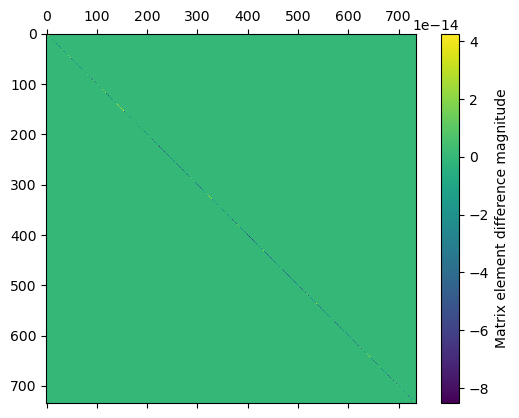

In [24]:
fig, ax = plt.subplots()
im = ax.matshow(full_hamiltonian-check_hamiltonian_1)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Matrix element difference magnitude')
plt.show()

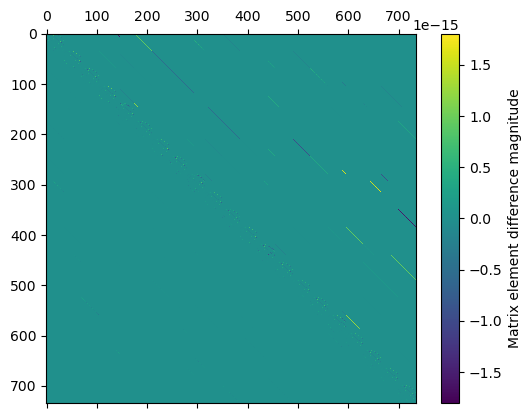

In [25]:
fig, ax = plt.subplots()
diffs = full_hamiltonian-check_hamiltonian_1
np.fill_diagonal(diffs, 0.0)
im = ax.matshow(diffs)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Matrix element difference magnitude')
plt.show()

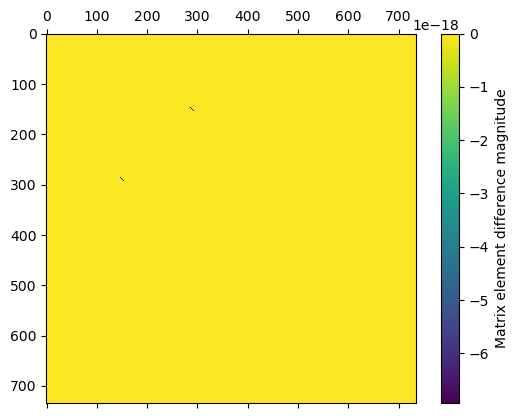

In [28]:
fig, ax = plt.subplots()
im = ax.matshow(check_hamiltonian_1-check_hamiltonian_2)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Matrix element difference magnitude')
plt.show()

# Final enlargement code

In [2]:
import hci
from hci import lib, HCI
from pyscf import gto, scf, ao2mo
import pyscf.fci as fci
from pyscf.fci.direct_spin1 import _unpack_nelec
from pyscf.fci import cistring
import numpy as np
import ctypes
from functools import reduce
import math
import matplotlib.pyplot as plt
myhci = hci.HCI()

In [3]:
mol = gto.M(
    atom = '''
O        0.000000    0.000000    0.117790
H        0.000000    0.755453   -0.471161
H        0.000000   -0.755453   -0.471161''',
    basis = 'sto-3g',
    charge = 1,
    spin = 1  # = 2S = spin_up - spin_down
)

mf = scf.UHF(mol)
mf.kernel()

nelec = _unpack_nelec(mol.nelectron, mol.spin)
nao = mol.nao_nr()
mo = mf.mo_coeff
norb = mo.shape[1]
hcore = mf.get_hcore()
eri_ao = mf._eri

mo_a, mo_b = mo
nelec_a, nelec_b = nelec
h1e_aa = reduce(np.dot, (mo_a.conj().T, hcore, mo_a))
h1e_bb = reduce(np.dot, (mo_b.conj().T, hcore, mo_b))
eri_mo_aaaa = ao2mo.restore('s8', ao2mo.full(eri_ao, mo_a), norb)
eri_mo_bbbb = ao2mo.restore('s8', ao2mo.full(eri_ao, mo_b), norb)
eri_mo_aabb = ao2mo.restore('s4', ao2mo.general(eri_ao, [mo_a, mo_a, mo_b, mo_b]), norb)

config_table_a, config_table_a_complement, config_table_b, config_table_b_complement, exc_table_4o, exc_table_2o = lib.get_ranking_tables(norb, nelec)

doubles_aa = lib.get_stored_double_exc(eri_mo_aaaa, exc_table_4o, norb)
max_mag_aa = lib.get_max_magnitudes(doubles_aa, norb)
sorted_indices = np.argsort(max_mag_aa)[::-1]
doubles_aa = doubles_aa[sorted_indices]
max_mag_aa = max_mag_aa[sorted_indices]

doubles_bb = lib.get_stored_double_exc(eri_mo_bbbb, exc_table_4o, norb)
max_mag_bb = lib.get_max_magnitudes(doubles_bb, norb)
sorted_indices = np.argsort(max_mag_bb)[::-1]
doubles_bb = doubles_bb[sorted_indices]
max_mag_bb = max_mag_bb[sorted_indices]

mixed_ab = lib.get_stored_mixed_exc(eri_mo_aabb, exc_table_2o, norb)
max_mag_ab = np.abs(mixed_ab['ijkl'])
sorted_indices = np.argsort(max_mag_ab)[::-1]
mixed_ab = mixed_ab[sorted_indices]
max_mag_ab = max_mag_ab[sorted_indices]

converged SCF energy = -74.6557767322148  <S^2> = 0.75520546  2S+1 = 2.0051987


In [7]:
thresh = 0.01

ranks = np.array([[1, 3], [2,4]], dtype=np.uint64)
coeffs = [np.array([0.707, 0.707], dtype=np.double)]

ranks_new, coeffs_new = myhci.enlarge_space(ranks, coeffs, norb, nelec_a, nelec_b, thresh,
                                            config_table_a, config_table_a_complement, 
                                            config_table_b, config_table_b_complement, exc_table_4o, exc_table_2o,
                                            doubles_aa, doubles_bb, mixed_ab, max_mag_aa, max_mag_bb, max_mag_ab,
                                            h1e_aa, h1e_bb, eri_mo_aaaa, eri_mo_bbbb, eri_mo_aabb)

print(ranks)
print(coeffs)
print(ranks_new)
print(coeffs_new)

[[1 3]
 [2 4]]
[array([0.707, 0.707])]
[[ 0  0]
 [ 0  1]
 [ 0  3]
 [ 0  8]
 [ 0 10]
 [ 0 22]
 [ 1  0]
 [ 1  1]
 [ 1  3]
 [ 1  4]
 [ 1 10]
 [ 1 11]
 [ 1 22]
 [ 1 23]
 [ 1 34]
 [ 2  0]
 [ 2  1]
 [ 2  3]
 [ 2  4]
 [ 2 10]
 [ 2 11]
 [ 2 14]
 [ 2 19]
 [ 2 22]
 [ 2 23]
 [ 2 34]
 [ 3 12]
 [ 3 18]
 [ 3 20]
 [ 4  0]
 [ 4  1]
 [ 4  3]
 [ 4  4]
 [ 4  8]
 [ 4 10]
 [ 4 14]
 [ 4 22]
 [ 5  0]
 [ 5  1]
 [ 5  4]
 [ 5  8]
 [ 6  2]
 [ 6 12]
 [ 6 20]
 [ 6 24]
 [ 7  2]
 [ 7 13]
 [ 7 21]
 [ 7 24]
 [ 8  3]
 [11  2]
 [11 13]
 [11 17]
 [11 21]
 [12  1]
 [12  3]
 [12  4]
 [12 10]
 [12 22]
 [13  2]
 [13 12]
 [13 20]
 [13 24]
 [14  2]
 [14 20]
 [14 24]
 [15  3]
 [15  4]
 [15 11]
 [15 14]
 [15 23]
 [16  2]
 [16 13]
 [16 21]
 [16 24]
 [17  2]
 [17 21]
 [17 24]
 [19  3]]
[array([0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.707,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.707, 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0. 

# Full CI Code

In [1]:
import hci
from hci import lib, HCI
from pyscf import gto, scf, ao2mo
import pyscf.fci as fci
from pyscf.fci.direct_spin1 import _unpack_nelec
from pyscf.fci import cistring, SCI
import numpy as np
import ctypes
from functools import reduce
import math
import matplotlib.pyplot as plt
myhci = hci.HCI()
mysci = SCI()

In [9]:
mol = gto.M(
    atom = '''
O        0.000000    0.000000    0.117790
H        0.000000    0.755453   -0.471161
H        0.000000   -0.755453   -0.471161''',
    basis = 'sto-3g',
    charge = 1,
    spin = 1  # = 2S = spin_up - spin_down
)
mol.output = 'test.log'

mf = scf.UHF(mol)
mf.kernel()

nelec = _unpack_nelec(mol.nelectron, mol.spin)
nelec_a, nelec_b = nelec
nao = mol.nao_nr()
mo = mf.mo_coeff
norb = mo.shape[1]
hcore = mf.get_hcore()
eri_ao = mf._eri
add_thresh = 0.01

# mf.mol.energy_nuc()
e, coeff = myhci.kernel(hcore, eri_ao, mo, norb, nelec, add_thresh, nroots=1, verbose=2)
print(e, len(coeff), math.comb(norb, nelec_a)*math.comb(norb, nelec_b))

converged SCF energy = -74.6557767322148  <S^2> = 0.75520546  2S+1 = 2.0051987
cycle 0  E = -83.8826728511022  dE = -83.882673
cycle 1  E = -83.8841224253185  dE = -0.0014495742
cycle 2  E = -83.8841232428942  dE = -8.1757568e-07
-83.88412327945062 169 735


In [10]:
mo_a, mo_b = mo
nelec_a, nelec_b = nelec
h1e_aa = reduce(np.dot, (mo_a.conj().T, hcore, mo_a))
h1e_bb = reduce(np.dot, (mo_b.conj().T, hcore, mo_b))
eri_mo_aaaa = ao2mo.restore('s8', ao2mo.full(eri_ao, mo_a), norb)
eri_mo_bbbb = ao2mo.restore('s8', ao2mo.full(eri_ao, mo_b), norb)
eri_mo_aabb = ao2mo.restore('s4', ao2mo.general(eri_ao, [mo_a, mo_a, mo_b, mo_b]), norb)
ndets = math.comb(norb, nelec[0])*math.comb(norb, nelec[1])
addr, full_hamiltonian = fci.direct_uhf.pspace((h1e_aa, h1e_bb), (eri_mo_aaaa, eri_mo_aabb, eri_mo_bbbb), norb, nelec, np=ndets)

In [11]:
eigenvalues, eigenvectors = np.linalg.eigh(full_hamiltonian)
print(eigenvalues[0])

-83.88412328780527


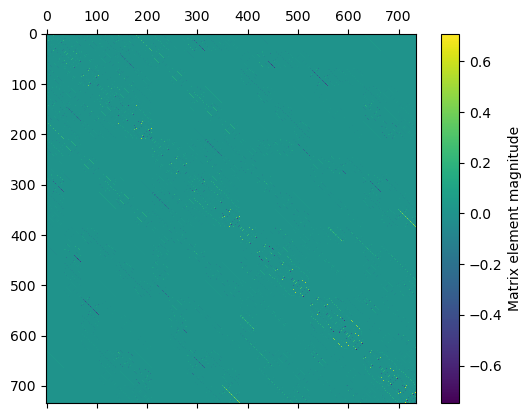

In [12]:
fig, ax = plt.subplots()
np.fill_diagonal(full_hamiltonian, 0.0)
im = ax.matshow(full_hamiltonian)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Matrix element magnitude')
plt.show()

# Trying again

In [13]:
mol = gto.Mole()
mol.output = None
mol.atom = [
    ['H', ( 1.,-1.    , 0.   )],
    ['H', ( 0.,-1.    ,-1.   )],
    ['H', ( 1.,-0.5   ,-1.   )],
    ['H', ( 0.,-0.    ,-1.   )],
    ['H', ( 1.,-0.5   , 0.   )],
    ['H', ( 0., 1.    , 1.   )],
    ['H', ( 1., 2.    , 3.   )],
    ['H', ( 1., 2.    , 4.   )],
]
mol.basis = 'sto-3g'
mol.build()

m = scf.RHF(mol)
m.kernel()
norb = m.mo_coeff.shape[1]
nelec = mol.nelectron
h1e = reduce(np.dot, (m.mo_coeff.T, m.get_hcore(), m.mo_coeff))
eri = ao2mo.kernel(m._eri, m.mo_coeff, compact=False)
eri = eri.reshape(norb,norb,norb,norb)

e1, c1 = mysci.kernel(h1e, eri, norb, nelec, verbose=2)
e2, c2 = fci.direct_spin1.kernel(h1e, eri, norb, nelec)
print(e1, c1.shape)
print(e2, c2.shape)
print(e1, e1 - -11.894559902235565, 'diff to FCI', e1-e2)

converged SCF energy = -3.65698303621992
-11.89470307918768 (60, 60)
-11.894725066101488 (70, 70)
-11.89470307918768 -0.00014317695211474302 diff to FCI 2.1986913807836572e-05


In [14]:
nelec = _unpack_nelec(mol.nelectron, mol.spin)
nelec_a, nelec_b = nelec
nao = mol.nao_nr()
mo = np.stack([m.mo_coeff, m.mo_coeff])
norb = mo.shape[1]
hcore = m.get_hcore()
eri_ao = m._eri
add_thresh = 0.01

e, coeff = myhci.kernel(hcore, eri_ao, mo, norb, nelec, add_thresh, nroots=1, verbose=2)
print(e, len(coeff), '/', math.comb(norb, nelec_a)*math.comb(norb, nelec_b), 'diff to FCI', e-e2)

cycle 0  E = -11.7941083442404  dE = -11.794108
cycle 1  E = -11.892795920037  dE = -0.098687576
cycle 2  E = -11.8947101714438  dE = -0.0019142514
-11.894723372017435 4900 / 4900 diff to FCI 1.694084053482925e-06


In [31]:
mol = gto.Mole()
mol.output = None
mol.atom = [
    ['H', (-0.8, 0., 0.)],
    ['H', (0.8, 0., 0.)],
]
mol.basis = 'aug-ccpvtz'
mol.build()

m = scf.RHF(mol)
m.kernel()
norb = m.mo_coeff.shape[1]
nelec = mol.nelectron
h1e = reduce(np.dot, (m.mo_coeff.T, m.get_hcore(), m.mo_coeff))
eri = ao2mo.kernel(m._eri, m.mo_coeff, compact=False)
eri = eri.reshape(norb,norb,norb,norb)

e1, c1 = mysci.kernel(h1e, eri, norb, nelec, verbose=2)
e2, c2 = fci.direct_spin1.kernel(h1e, eri, norb, nelec)
print(e1, c1.shape)
print(e2, c2.shape)
print(e1, e1 - -11.894559902235565, 'diff to FCI', e1-e2)

converged SCF energy = -0.986854363533285
-1.3856391898546507 (46, 46)
-1.3856391898578768 (46, 46)
-1.3856391898546507 10.508920712380915 diff to FCI 3.22608606495578e-12


In [32]:
nelec = _unpack_nelec(mol.nelectron, mol.spin)
nelec_a, nelec_b = nelec
nao = mol.nao_nr()
mo = np.stack([m.mo_coeff, m.mo_coeff])
norb = mo.shape[1]
hcore = m.get_hcore()
eri_ao = m._eri
add_thresh = 0.01

e, coeff = myhci.kernel(hcore, eri_ao, mo, norb, nelec, add_thresh, nroots=1, verbose=2)
print(e, len(coeff), '/', math.comb(norb, nelec_a)*math.comb(norb, nelec_b), 'diff to FCI', e-e2)

cycle 0  E = -1.38078133671734  dE = -1.3807813
cycle 1  E = -1.38563912503804  dE = -0.0048577883
cycle 2  E = -1.38563918527974  dE = -6.0241697e-08
-1.3856391893626863 2116 / 2116 diff to FCI 4.951905552275093e-10


In [30]:
print(norb)

46


In [ ]:
mol = gto.Mole()
mol.output = None
mol.atom = [
    ['H', (-0.8, 0., 0.)],
    ['H', (0.8, 0., 0.)],
]
mol.basis = 'aug-ccpvqz'
mol.build()

m = scf.RHF(mol)
m.kernel()
norb = m.mo_coeff.shape[1]
nelec = mol.nelectron
h1e = reduce(np.dot, (m.mo_coeff.T, m.get_hcore(), m.mo_coeff))
eri = ao2mo.kernel(m._eri, m.mo_coeff, compact=False)
eri = eri.reshape(norb,norb,norb,norb)

e1, c1 = mysci.kernel(h1e, eri, norb, nelec, verbose=2)
e2, c2 = fci.direct_spin1.kernel(h1e, eri, norb, nelec)
print(e1, c1.shape)
print(e2, c2.shape)
print(e1, e1 - -11.894559902235565, 'diff to FCI', e1-e2)

converged SCF energy = -0.987112723277713


In [ ]:
nelec = _unpack_nelec(mol.nelectron, mol.spin)
nelec_a, nelec_b = nelec
nao = mol.nao_nr()
mo = np.stack([m.mo_coeff, m.mo_coeff])
norb = mo.shape[1]
hcore = m.get_hcore()
eri_ao = m._eri
add_thresh = 0.01

e, coeff = myhci.kernel(hcore, eri_ao, mo, norb, nelec, add_thresh, nroots=1, verbose=2)
print(e, len(coeff), '/', math.comb(norb, nelec_a)*math.comb(norb, nelec_b), 'diff to FCI', e-e2)

In [ ]:
print(norb)

# Double checking contraction

In [33]:
import hci
from hci import lib, HCI
from pyscf import gto, scf, ao2mo
import pyscf.fci as fci
from pyscf.fci.direct_spin1 import _unpack_nelec, absorb_h1e
from pyscf.fci import cistring, SCI
from pyscf.fci.selected_ci import _as_SCIvector, to_fci
import numpy as np
import ctypes
from functools import reduce
import math
import matplotlib.pyplot as plt
myhci = hci.HCI()
mysci = SCI()

In [34]:
mol = gto.Mole()
mol.output = None
mol.atom = [
    ['H', ( 1.,-1.    , 0.   )],
    ['H', ( 0.,-1.    ,-1.   )],
    ['H', ( 1.,-0.5   ,-1.   )],
    ['H', ( 0.,-0.    ,-1.   )],
    ['H', ( 1.,-0.5   , 0.   )],
    ['H', ( 0., 1.    , 1.   )],
    ['H', ( 1., 2.    , 3.   )],
    ['H', ( 1., 2.    , 4.   )],
]
mol.basis = 'sto-3g'
mol.build()

m = scf.RHF(mol)
m.kernel()
norb = m.mo_coeff.shape[1]
nelec = _unpack_nelec(mol.nelectron, mol.spin)
nelec_a, nelec_b = nelec
h1e = reduce(np.dot, (m.mo_coeff.T, m.get_hcore(), m.mo_coeff))
eri = ao2mo.kernel(m._eri, m.mo_coeff, compact=False)
eri = eri.reshape(norb,norb,norb,norb)

h2e = absorb_h1e(h1e, eri, norb, nelec, .5)
h2e = ao2mo.restore(1, h2e, norb)

h1e_aa = h1e
h1e_bb = h1e.copy()
eri_aaaa_s8 = ao2mo.restore('s8', eri, norb)
eri_bbbb_s8 = eri_aaaa_s8.copy()
eri_aabb_s4 = ao2mo.restore('s4', eri, norb)

config_table_a, config_table_a_complement, config_table_b, config_table_b_complement, exc_table_4o, exc_table_2o = lib.get_ranking_tables(norb, nelec)

converged SCF energy = -3.65698303621992


In [35]:
hci_ranks = np.array([[0, 0], [1, 0], [0, 1], [1, 1]], dtype=np.uint64)
hci_coeffs = np.array([0.5, 0.5, 0.5, 0.5], dtype=np.double)
ci_strs, sci_coeffs = lib.hci_to_sci(hci_ranks, hci_coeffs, config_table_a, config_table_b, norb, nelec_a, nelec_b)
print(ci_strs)
print(sci_coeffs)

[[0 1 2 3]
 [0 1 2 4]]
[[0 1 2 3]
 [0 1 2 4]]
(array([15, 23]), array([15, 23]))
[[0.5 0.5]
 [0.5 0.5]]


In [36]:
new_sci_coeffs = mysci.contract_2e(h2e, _as_SCIvector(sci_coeffs, ci_strs), norb, nelec)
print(sci_coeffs)
print(new_sci_coeffs)

[[0.5 0.5]
 [0.5 0.5]]
[[-5.80238971 -5.8692661 ]
 [-5.8692661  -5.65963686]]


In [37]:
ndets = math.comb(norb, nelec[0])*math.comb(norb, nelec[1])
addr, full_hamiltonian = fci.direct_uhf.pspace((h1e, h1e), (eri_aaaa_s8, eri_aabb_s4, eri_bbbb_s8), norb, nelec, np=ndets)

In [38]:
sci_vec = _as_SCIvector(sci_coeffs, ci_strs)
fci_vec = to_fci(sci_vec, norb, nelec)
print(fci_vec)
print(fci_vec.shape)

[[0.5 0.5 0.  ... 0.  0.  0. ]
 [0.5 0.5 0.  ... 0.  0.  0. ]
 [0.  0.  0.  ... 0.  0.  0. ]
 ...
 [0.  0.  0.  ... 0.  0.  0. ]
 [0.  0.  0.  ... 0.  0.  0. ]
 [0.  0.  0.  ... 0.  0.  0. ]]
(70, 70)


In [39]:
(full_hamiltonian @ fci_vec.ravel()).reshape(math.comb(norb, nelec[0]), math.comb(norb, nelec[1]))[:2, :2]

array([[-5.80238971, -5.8692661 ],
       [-5.8692661 , -5.65963686]])

In [40]:
hdiag = lib.make_hdiag_slow(hci_ranks, 
                            config_table_a, config_table_b, norb, nelec_a, nelec_b, 
                            h1e_aa, h1e_bb, eri_aaaa_s8, eri_bbbb_s8, eri_aabb_s4)
new_hci_coeffs = lib.contract_hamiltonian_hcivec_slow(hci_ranks, hci_coeffs, hdiag,
                                                      config_table_a, config_table_b, norb, nelec_a, nelec_b,
                                                      h1e_aa, h1e_bb, eri_aaaa_s8, eri_bbbb_s8, eri_aabb_s4)
print(hci_coeffs)
print(new_hci_coeffs)

[0.5 0.5 0.5 0.5]
[-5.80238971 -5.8692661  -5.8692661  -5.65963686]


# After the Great Refactoring

In [1]:
import hci
from hci import lib, HCI
from hci.lib import CoreHamiltonian, ElectronRepulsionIntegrals, ConfigInfo, ExcitationEntries, HCIVector, Rank
from pyscf import gto, scf, ao2mo
import pyscf.fci as fci
from pyscf.fci.direct_spin1 import _unpack_nelec, absorb_h1e
from pyscf.fci import cistring, SCI
from pyscf.fci.selected_ci import _as_SCIvector, to_fci
import numpy as np
import ctypes
from functools import reduce
import math
import matplotlib.pyplot as plt
import ctypes as ct
myhci = hci.HCI()
mysci = SCI()

In [2]:
mol = gto.M(
    atom = '''
O        0.000000    0.000000    0.117790
H        0.000000    0.755453   -0.471161
H        0.000000   -0.755453   -0.471161''',
    basis = 'sto-3g',
    charge = 1,
    spin = 1  # = 2S = spin_up - spin_down
)

mf = scf.UHF(mol)
mf.kernel()

nelec = _unpack_nelec(mol.nelectron, mol.spin)
nelec_a, nelec_b = nelec
nao = mol.nao_nr()
mo = mf.mo_coeff
mo_a, mo_b = mo

norb = mo.shape[1]
hcore = mf.get_hcore()
eri_ao = mf._eri
add_thresh = 0.01

converged SCF energy = -74.6557767322148  <S^2> = 0.75520546  2S+1 = 2.0051987


In [3]:
h1e_mo_aa = reduce(np.dot, (mo_a.conj().T, hcore, mo_a))
h1e_mo_bb = reduce(np.dot, (mo_b.conj().T, hcore, mo_b))
h1e = CoreHamiltonian(h1e_mo_aa, h1e_mo_bb)

eri_mo_aaaa_s8 = ao2mo.restore('s8', ao2mo.full(eri_ao, mo_a), norb)
eri_mo_bbbb_s8 = ao2mo.restore('s8', ao2mo.full(eri_ao, mo_b), norb)
eri_mo_aabb_s4 = ao2mo.restore('s4', ao2mo.general(eri_ao, [mo_a, mo_a, mo_b, mo_b]), norb)
eri_mo = ElectronRepulsionIntegrals(eri_mo_aaaa_s8, eri_mo_bbbb_s8, eri_mo_aabb_s4)

In [4]:
config_info = ConfigInfo(norb, nelec)
excitation_entries = ExcitationEntries(eri_mo, config_info)
excitation_entries.sort_desc_by_mag()

In [5]:
ci0 = None
if ci0 is None:
    ranks = np.zeros(1, dtype=lib.rank_entry)
    hf_gnd = HCIVector.as_HCIVector(np.array([1.0], dtype=np.float64), ranks)
    ci0 = [hf_gnd]
    ci0 = myhci.enlarge_space_new(ci0, add_thresh, config_info, excitation_entries, h1e, eri_mo)

[(18,  0) (12,  0) (19,  0) ( 0, 28) ( 0, 25) ( 0, 29) ( 8, 16) ( 4,  7)
 ( 8,  7) ( 4, 16) ( 1, 16) ( 3,  6) ( 8,  5) ( 1,  7) ( 6, 15) ( 1,  5)
 ( 2,  3) ( 4,  5) ( 9, 17) ( 6,  6) ( 3, 17) ( 3, 15) ( 9,  6) ( 5,  8)
 ( 7,  2) (10, 18) ( 9, 18) ( 2,  4) (10, 17) ( 9, 15) (10, 15)]
[]


# Comparison to before

In [6]:
mo_a, mo_b = mo
nelec_a, nelec_b = nelec
h1e_aa = reduce(np.dot, (mo_a.conj().T, hcore, mo_a))
h1e_bb = reduce(np.dot, (mo_b.conj().T, hcore, mo_b))
eri_aaaa_s8 = ao2mo.restore('s8', ao2mo.full(eri_ao, mo_a), norb)
eri_bbbb_s8 = ao2mo.restore('s8', ao2mo.full(eri_ao, mo_b), norb)
eri_aabb_s4 = ao2mo.restore('s4', ao2mo.general(eri_ao, [mo_a, mo_a, mo_b, mo_b]), norb)

In [7]:
config_table_a, config_table_a_complement, config_table_b, config_table_b_complement, exc_table_4o, exc_table_2o = lib.get_ranking_tables(norb, nelec)

In [8]:
doubles_aa = lib.get_stored_double_exc(eri_aaaa_s8, exc_table_4o, norb)
max_mag_aa = lib.get_max_magnitudes(doubles_aa)
sorted_indices = np.argsort(max_mag_aa)[::-1]
doubles_aa = doubles_aa[sorted_indices]
max_mag_aa = max_mag_aa[sorted_indices]

doubles_bb = lib.get_stored_double_exc(eri_bbbb_s8, exc_table_4o, norb)
max_mag_bb = lib.get_max_magnitudes(doubles_bb)
sorted_indices = np.argsort(max_mag_bb)[::-1]
doubles_bb = doubles_bb[sorted_indices]
max_mag_bb = max_mag_bb[sorted_indices]

mixed_ab = lib.get_stored_mixed_exc(eri_aabb_s4, exc_table_2o, norb)
max_mag_ab = np.abs(mixed_ab['ijkl'])
sorted_indices = np.argsort(max_mag_ab)[::-1]
mixed_ab = mixed_ab[sorted_indices]
max_mag_ab = max_mag_ab[sorted_indices]

In [9]:
ci0 = None
if ci0 is None:
    ranks = np.array([[0, 0]], dtype=np.uint64)
    coeffs = [np.array([1.0], dtype=np.double)]
    ranks, coeffs = myhci.enlarge_space(ranks, coeffs, norb, nelec_a, nelec_b, add_thresh,
                                        config_table_a, config_table_a_complement, config_table_b, config_table_b_complement, exc_table_4o, exc_table_2o,
                                        doubles_aa, doubles_bb, mixed_ab, max_mag_aa, max_mag_bb, max_mag_ab,
                                        h1e_aa, h1e_bb, eri_aaaa_s8, eri_bbbb_s8, eri_aabb_s4)

[[18  0]
 [12  0]
 [19  0]
 [ 0 28]
 [ 0 25]
 [ 0 29]
 [ 8 16]
 [ 4  7]
 [ 8  7]
 [ 4 16]
 [ 1 16]
 [ 3  6]
 [ 8  5]
 [ 1  7]
 [ 6 15]
 [ 1  5]
 [ 2  3]
 [ 4  5]
 [ 9 17]
 [ 6  6]
 [ 3 17]
 [ 3 15]
 [ 9  6]
 [ 5  8]
 [ 7  2]
 [10 18]
 [ 9 18]
 [ 2  4]
 [10 17]
 [ 9 15]
 [10 15]]
[]


In [10]:
hci.lib.get_matrix_element_by_rank_new(Rank(0, 0), Rank(12, 0), config_info, h1e, eri_mo)

-0.029677964690103746

In [11]:
hci.lib.get_matrix_element_by_rank(0, 0, 12, 0,
                                   config_table_a, config_table_b, norb, nelec_a, nelec_b,
                                   h1e_aa, h1e_bb, eri_aaaa_s8, eri_bbbb_s8, eri_aabb_s4)

-0.029677964690103746

In [12]:
out = np.empty(5, dtype=np.uint64)
hci.lib.unrank(0, out, config_table_a, norb, nelec_a)
out

array([0, 1, 2, 3, 4], dtype=uint64)

In [13]:
out = np.empty(5, dtype=np.uint64)
hci.lib.unrank(12, out, config_table_a, norb, nelec_a)
out

array([0, 1, 3, 5, 6], dtype=uint64)

In [14]:
eri_aaaa_s1 = ao2mo.restore('s1', eri_aaaa_s8, norb)
-1*(eri_aaaa_s1[2,5,4,6]-eri_aaaa_s1[2,6,4,5])

np.float64(-0.029677964690103746)

# Matrix Elements

In [15]:
import hci
from hci import lib, HCI
from hci.lib import CoreHamiltonian, ElectronRepulsionIntegrals, ConfigInfo, ExcitationEntries, HCIVector, Rank
from pyscf import gto, scf, ao2mo
import pyscf.fci as fci
from pyscf.fci.direct_spin1 import _unpack_nelec, absorb_h1e
from pyscf.fci import cistring, SCI
from pyscf.fci.selected_ci import _as_SCIvector, to_fci
import numpy as np
import ctypes
from functools import reduce
import math
import matplotlib.pyplot as plt
import ctypes as ct
import itertools
myhci = hci.HCI()
mysci = SCI()

rng = np.random.default_rng()

In [16]:
def generate_mock_h1e(N):
    h1e = np.zeros((N,N), dtype=np.float64)
    for (a,b) in itertools.combinations(reversed(range(N)),2):
        rand1 = rng.random()
        h1e[a,b] = rand1
        h1e[b,a] = rand1
    for i in range(N):
        h1e[i,i] = rng.random()
    return h1e

def generate_mock_eri_s4(N):
    eri = np.zeros((N,N,N,N), dtype=np.float64)
    for (a,b,c,d) in itertools.combinations(reversed(range(N)),4):
        rand1 = rng.random()
        rand2 = rng.random()
        rand3 = rng.random()
        rand4 = rng.random()
        rand5 = rng.random()
        rand6 = rng.random()
        
        index1 = (a,b,c,d)
        eri[a,b,c,d] = rand1
        eri[a,b,d,c] = rand1
        eri[b,a,c,d] = rand1
        eri[b,a,d,c] = rand1

        index2 = (c,d,a,b)
        eri[c,d,a,b] = rand2
        eri[d,c,a,b] = rand2
        eri[c,d,b,a] = rand2
        eri[d,c,b,a] = rand2
        
        index3 = (a,c,b,d)
        eri[a,c,b,d] = rand3
        eri[a,c,d,b] = rand3
        eri[c,a,b,d] = rand3
        eri[c,a,d,b] = rand3

        index4 = (b,d,a,c)
        eri[b,d,a,c] = rand4
        eri[d,b,a,c] = rand4
        eri[b,d,c,a] = rand4
        eri[d,b,c,a] = rand4

        index5 = (a,d,b,c)
        eri[a,d,b,c] = rand5
        eri[a,d,c,b] = rand5
        eri[d,a,b,c] = rand5
        eri[d,a,c,b] = rand5

        index6 = (b,c,a,d)
        eri[b,c,a,d] = rand6
        eri[c,b,a,d] = rand6
        eri[b,c,d,a] = rand6
        eri[c,b,d,a] = rand6

    for (a,b,c) in itertools.combinations(reversed(range(N)),3):
        rand1 = rng.random()
        rand2 = rng.random()
        rand3 = rng.random()
        rand4 = rng.random()
        rand5 = rng.random()
        rand6 = rng.random()
        rand7 = rng.random()
        rand8 = rng.random()
        rand9 = rng.random()
        rand10 = rng.random()
        rand11 = rng.random()
        rand12 = rng.random()
        
        index1 = (a,a,b,c)
        eri[a,a,b,c] = rand1
        eri[a,a,c,b] = rand1

        index2 = (b,c,a,a)
        eri[b,c,a,a] = rand2
        eri[c,b,a,a] = rand2
        
        index3 = (a,b,a,c)
        eri[a,b,a,c] = rand3
        eri[a,b,c,a] = rand3
        eri[b,a,a,c] = rand3
        eri[b,a,c,a] = rand3

        index4 = (a,c,a,b)
        eri[a,c,a,b] = rand4
        eri[c,a,a,b] = rand4
        eri[a,c,b,a] = rand4
        eri[c,a,b,a] = rand4

        index5 = (a,c,b,b)
        eri[a,c,b,b] = rand5
        eri[c,a,b,b] = rand5

        index6 = (b,b,a,c)
        eri[b,b,a,c] = rand6
        eri[b,b,c,a] = rand6
        
        index7 = (a,b,b,c)
        eri[a,b,b,c] = rand7
        eri[a,b,c,b] = rand7
        eri[b,a,b,c] = rand7
        eri[b,a,c,b] = rand7

        index8 = (b,c,a,b)
        eri[b,c,a,b] = rand8
        eri[c,b,a,b] = rand8
        eri[b,c,b,a] = rand8
        eri[c,b,b,a] = rand8
    
        index9 = (a,b,c,c)
        eri[a,b,c,c] = rand9
        eri[b,a,c,c] = rand9

        index10 = (c,c,a,b)
        eri[c,c,a,b] = rand10
        eri[c,c,b,a] = rand10
        
        index11 = (a,c,b,c)
        eri[a,c,b,c] = rand11
        eri[a,c,c,b] = rand11
        eri[c,a,b,c] = rand11
        eri[c,a,c,b] = rand11

        index12 = (b,c,a,c)
        eri[b,c,a,c] = rand12
        eri[c,b,a,c] = rand12
        eri[b,c,c,a] = rand12
        eri[c,b,c,a] = rand12

    for (a,b) in itertools.combinations(reversed(range(N)),2):
        rand1 = rng.random()
        rand2 = rng.random()
        rand3 = rng.random()
        rand4 = rng.random()
        rand5 = rng.random()
        rand6 = rng.random()
        rand7 = rng.random()

        index1 = (a,a,b,b)
        eri[a,a,b,b] = rand1

        index2 = (b,b,a,a)
        eri[b,b,a,a] = rand2

        index3 = (a,b,a,b)
        eri[a,b,a,b] = rand3
        eri[a,b,b,a] = rand3
        eri[b,a,a,b] = rand3
        eri[b,a,b,a] = rand3

        index4 = (a,a,a,b)
        eri[a,a,a,b] = rand4
        eri[a,a,b,a] = rand4

        index5 = (a,b,a,a)
        eri[a,b,a,a] = rand5
        eri[b,a,a,a] = rand5

        index6 = (b,b,a,b)
        eri[b,b,b,a] = rand6
        eri[b,b,a,b] = rand6

        index7 = (a,b,b,b)
        eri[b,a,b,b] = rand7
        eri[a,b,b,b] = rand7

    for a in range(N):
        index1 = (a,a,a,a)
        eri[a,a,a,a] = rng.random()

    return eri

def generate_mock_eri_s8(N):
    eri = np.zeros((N,N,N,N))
    for (a,b,c,d) in itertools.combinations(reversed(range(N)),4):
        rand1 = rng.random()
        rand2 = rng.random()
        rand3 = rng.random()
        
        index1 = (a,b,c,d)
        eri[a,b,c,d] = rand1
        eri[a,b,d,c] = rand1
        eri[b,a,c,d] = rand1
        eri[b,a,d,c] = rand1
        eri[c,d,a,b] = rand1
        eri[d,c,a,b] = rand1
        eri[c,d,b,a] = rand1
        eri[d,c,b,a] = rand1
        
        index2 = (a,c,b,d)
        eri[a,c,b,d] = rand2
        eri[a,c,d,b] = rand2
        eri[c,a,b,d] = rand2
        eri[c,a,d,b] = rand2
        eri[b,d,a,c] = rand2
        eri[d,b,a,c] = rand2
        eri[b,d,c,a] = rand2
        eri[d,b,c,a] = rand2
        
        index3 = (a,d,b,c)
        eri[a,d,b,c] = rand3
        eri[a,d,c,b] = rand3
        eri[d,a,b,c] = rand3
        eri[d,a,c,b] = rand3
        eri[b,c,a,d] = rand3
        eri[c,b,a,d] = rand3
        eri[b,c,d,a] = rand3
        eri[c,b,d,a] = rand3

    for (a,b,c) in itertools.combinations(reversed(range(N)),3):
        rand1 = rng.random()
        rand2 = rng.random()
        rand3 = rng.random()
        rand4 = rng.random()
        rand5 = rng.random()
        rand6 = rng.random()
        
        index1 = (a,a,b,c)
        eri[a,a,b,c] = rand1
        eri[a,a,c,b] = rand1
        eri[b,c,a,a] = rand1
        eri[c,b,a,a] = rand1
        
        index2 = (a,b,a,c)
        eri[a,b,a,c] = rand2
        eri[a,b,c,a] = rand2
        eri[b,a,a,c] = rand2
        eri[b,a,c,a] = rand2
        eri[a,c,a,b] = rand2
        eri[c,a,a,b] = rand2
        eri[a,c,b,a] = rand2
        eri[c,a,b,a] = rand2

        index3 = (a,c,b,b)
        eri[a,c,b,b] = rand3
        eri[c,a,b,b] = rand3
        eri[b,b,a,c] = rand3
        eri[b,b,c,a] = rand3
        
        index4 = (a,b,b,c)
        eri[a,b,b,c] = rand4
        eri[a,b,c,b] = rand4
        eri[b,a,b,c] = rand4
        eri[b,a,c,b] = rand4
        eri[b,c,a,b] = rand4
        eri[c,b,a,b] = rand4
        eri[b,c,b,a] = rand4
        eri[c,b,b,a] = rand4
    
        index5 = (a,b,c,c)
        eri[a,b,c,c] = rand5
        eri[b,a,c,c] = rand5
        eri[c,c,a,b] = rand5
        eri[c,c,b,a] = rand5
        
        index6 = (a,c,b,c)
        eri[a,c,b,c] = rand6
        eri[a,c,c,b] = rand6
        eri[c,a,b,c] = rand6
        eri[c,a,c,b] = rand6
        eri[b,c,a,c] = rand6
        eri[c,b,a,c] = rand6
        eri[b,c,c,a] = rand6
        eri[c,b,c,a] = rand6

    for (a,b) in itertools.combinations(reversed(range(N)),2):
        rand1 = rng.random()
        rand2 = rng.random()
        rand3 = rng.random()
        rand4 = rng.random()

        index1 = (a,a,b,b)
        eri[a,a,b,b] = rand1
        eri[b,b,a,a] = rand1

        index2 = (a,b,a,b)
        eri[a,b,a,b] = rand2
        eri[a,b,b,a] = rand2
        eri[b,a,a,b] = rand2
        eri[b,a,b,a] = rand2

        index3 = (a,a,a,b)
        eri[a,a,a,b] = rand3
        eri[a,a,b,a] = rand3
        eri[a,b,a,a] = rand3
        eri[b,a,a,a] = rand3

        index4 = (a,b,b,b)
        eri[b,b,b,a] = rand4
        eri[b,b,a,b] = rand4
        eri[b,a,b,b] = rand4
        eri[a,b,b,b] = rand4

    for a in range(N):
        index1 = (a,a,a,a)
        eri[a,a,a,a] = rng.random()

    return eri

In [17]:
norb = 7
nelec = (5, 4)
nelec_a, nelec_b = nelec

h1e_mo_aa = generate_mock_h1e(norb)
h1e_mo_bb = generate_mock_h1e(norb)
h1e = CoreHamiltonian(h1e_mo_aa, h1e_mo_bb)

eri_mo_aaaa_s8 = ao2mo.restore('s8', generate_mock_eri_s8(norb), norb)
eri_mo_bbbb_s8 = ao2mo.restore('s8', generate_mock_eri_s8(norb), norb)
eri_mo_aabb_s4 = ao2mo.restore('s4', generate_mock_eri_s4(norb), norb)
eri_mo = ElectronRepulsionIntegrals(eri_mo_aaaa_s8, eri_mo_bbbb_s8, eri_mo_aabb_s4)

In [18]:
print(eri_mo_aaaa_s8.shape)

(406,)


In [19]:
config_info = ConfigInfo(norb, nelec)
excitation_entries = ExcitationEntries(eri_mo, config_info)

In [20]:
ndets = math.comb(norb, nelec[0])*math.comb(norb, nelec[1])
addr, full_hamiltonian = fci.direct_uhf.pspace((h1e_mo_aa, h1e_mo_bb), (eri_mo_aaaa_s8, eri_mo_aabb_s4, eri_mo_bbbb_s8), norb, nelec, np=ndets)

In [21]:
na = cistring.num_strings(norb, nelec_a)
nb = cistring.num_strings(norb, nelec_b)
addr = np.arange(na*nb)
addra = addr // nb
addrb = addr % nb
stra = cistring.addrs2str(norb, nelec_a, addra)
strb = cistring.addrs2str(norb, nelec_b, addrb)
occlsta = cistring._strs2occslst(stra, norb).astype(np.uintp)
occlstb = cistring._strs2occslst(strb, norb).astype(np.uintp)
ranka = np.zeros(na*nb, dtype=np.uint64)
rankb = np.zeros(na*nb, dtype=np.uint64)

In [22]:
for i, occs in enumerate(occlsta):
    ranka[i] = hci.lib.rank(occs, config_info.config_table_a, norb, nelec_a)

for i, occs in enumerate(occlstb):
    rankb[i] = hci.lib.rank(occs, config_info.config_table_b, norb, nelec_b)

In [23]:
check_hamiltonian_1 = np.zeros((full_hamiltonian.shape[0], full_hamiltonian.shape[1]))
check_hamiltonian_2 = np.zeros((full_hamiltonian.shape[0], full_hamiltonian.shape[1]))
for i in range(full_hamiltonian.shape[0]):
    ranka_1 = ranka[i]
    rankb_1 = rankb[i]
    for j in range(full_hamiltonian.shape[1]):
        ranka_2 = ranka[j]
        rankb_2 = rankb[j]
        check_hamiltonian_1[i,j] = hci.lib.get_matrix_element_by_rank_test_storage_new(Rank(ranka_1, rankb_1), Rank(ranka_2, rankb_2), 
                                                                                       config_info, excitation_entries, h1e, eri_mo)
        check_hamiltonian_2[i,j] = hci.lib.get_matrix_element_by_rank_new(Rank(ranka_1, rankb_1), Rank(ranka_2, rankb_2), 
                                                                          config_info, h1e, eri_mo)

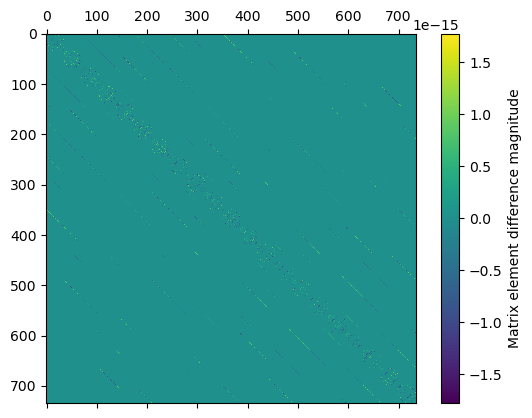

In [24]:
fig, ax = plt.subplots()
diffs = full_hamiltonian-check_hamiltonian_1
np.fill_diagonal(diffs, 0.0)
im = ax.matshow(diffs)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Matrix element difference magnitude')
plt.show()

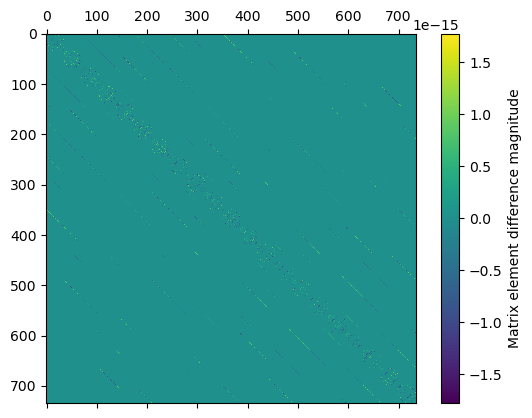

In [25]:
fig, ax = plt.subplots()
diffs = full_hamiltonian-check_hamiltonian_2
np.fill_diagonal(diffs, 0.0)
im = ax.matshow(diffs)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Matrix element difference magnitude')
plt.show()

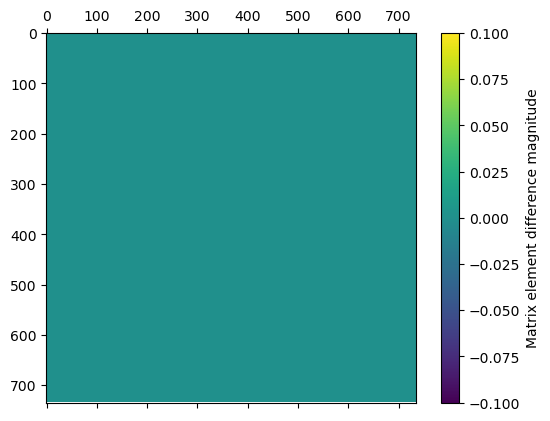

In [26]:
fig, ax = plt.subplots()
diffs = check_hamiltonian_1-check_hamiltonian_2
np.fill_diagonal(diffs, 0.0)
im = ax.matshow(diffs)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Matrix element difference magnitude')
plt.show()

In [27]:
np.max(check_hamiltonian_1-check_hamiltonian_2)

np.float64(0.0)

In [29]:
np.max(full_hamiltonian-check_hamiltonian_1)

np.float64(1.0658141036401503e-14)

In [30]:
np.max(full_hamiltonian-check_hamiltonian_2)

np.float64(1.0658141036401503e-14)

# Final checks before breaking changes

In [1]:
import hci
from hci import lib, HCI
from hci.lib import CoreHamiltonian, ElectronRepulsionIntegrals, ConfigInfo, ExcitationEntries, HCIVector, Rank
from pyscf import gto, scf, ao2mo
import pyscf.fci as fci
from pyscf.fci.direct_spin1 import _unpack_nelec, absorb_h1e
from pyscf.fci import cistring, SCI
from pyscf.fci.selected_ci import _as_SCIvector, to_fci
from pyscf.lib import davidson
import numpy as np
import ctypes
from functools import reduce
import math
import matplotlib.pyplot as plt
import ctypes as ct
import itertools
myhci = hci.HCI()
mysci = SCI()

rng = np.random.default_rng()

In [2]:
mol = gto.M(
    atom = '''
O        0.000000    0.000000    0.117790
H        0.000000    0.755453   -0.471161
H        0.000000   -0.755453   -0.471161''',
    basis = 'sto-3g',
    charge = 1,
    spin = 1  # = 2S = spin_up - spin_down
)

mf = scf.UHF(mol)
mf.kernel()

nelec = _unpack_nelec(mol.nelectron, mol.spin)
nelec_a, nelec_b = nelec
nao = mol.nao_nr()
mo = mf.mo_coeff
mo_a, mo_b = mo

norb = mo.shape[1]
hcore = mf.get_hcore()
eri_ao = mf._eri
add_thresh = 0.01

converged SCF energy = -74.6557767322147  <S^2> = 0.75520546  2S+1 = 2.0051987


In [3]:
e, coeff = myhci.kernel_new(hcore, eri_ao, mo, norb, nelec, add_thresh, nroots=1, verbose=2)

[(18,  0) (12,  0) (19,  0) ( 0, 28) ( 0, 25) ( 0, 29) ( 8, 16) ( 4,  7)
 ( 8,  7) ( 4, 16) ( 1, 16) ( 3,  6) ( 8,  5) ( 1,  7) ( 6, 15) ( 1,  5)
 ( 2,  3) ( 4,  5) ( 9, 17) ( 6,  6) ( 3, 17) ( 3, 15) ( 9,  6) ( 5,  8)
 ( 7,  2) (10, 18) ( 9, 18) ( 2,  4) (10, 17) ( 9, 15) (10, 15)]
[]
cycle 0  E = -83.8830202823992  dE = -83.88302
[(18, 0) (12, 0) (19, 0) ... (18, 5) (12, 8) ( 8, 5)]
[( 5, 25) ( 4, 25) ( 8, 25) ( 1, 25) ( 0, 29) ( 0, 28) ( 0, 16) ( 0,  5)
 ( 5, 28) ( 4, 28) ( 8, 28) ( 1, 28) ( 0, 29) ( 0, 25) ( 0, 16) ( 0,  7)
 ( 5, 29) ( 4, 29) ( 8, 29) ( 1, 29) ( 0, 28) ( 0, 25) ( 0, 16) ( 0,  8)
 ( 5,  5) ( 4,  5) (12,  5) ( 0,  5) ( 1,  8) ( 1,  7) ( 1, 25) ( 1,  0)
 ( 5,  7) ( 4,  7) (12,  7) ( 0,  7) ( 1,  8) ( 1, 28) ( 1,  5) ( 1,  0)
 ( 5, 16) ( 4, 16) (12, 16) ( 0, 16) ( 1, 29) ( 1, 28) ( 1, 25) ( 1,  0)
 (15,  3) ( 2,  4) ( 2, 14) ( 2, 22) ( 2,  1) ( 2, 10) (15,  4) ( 2,  3)
 ( 2, 14) ( 2, 23) ( 2,  1) ( 2, 11) ( 3, 18) ( 3, 27) ( 3, 17) ( 3, 26)
 ( 3, 18) ( 3, 30) ( 3, 15) 

In [4]:
h1e_mo_aa = reduce(np.dot, (mo_a.conj().T, hcore, mo_a))
h1e_mo_bb = reduce(np.dot, (mo_b.conj().T, hcore, mo_b))

eri_mo_aaaa_s8 = ao2mo.restore('s8', ao2mo.full(eri_ao, mo_a), norb)
eri_mo_bbbb_s8 = ao2mo.restore('s8', ao2mo.full(eri_ao, mo_b), norb)
eri_mo_aabb_s4 = ao2mo.restore('s4', ao2mo.general(eri_ao, [mo_a, mo_a, mo_b, mo_b]), norb)

In [5]:
ndets = math.comb(norb, nelec[0])*math.comb(norb, nelec[1])
addr, full_hamiltonian = fci.direct_uhf.pspace((h1e_mo_aa, h1e_mo_bb), (eri_mo_aaaa_s8, eri_mo_aabb_s4, eri_mo_bbbb_s8), norb, nelec, np=ndets)
eigenvalues, eigenvectors = np.linalg.eigh(full_hamiltonian)
print(eigenvalues[0])

-83.88412328780528


In [1]:
import numpy as np

In [270]:
arr = np.array([[0,1,2],
                [2,1,0],
                [2,0,1],
                [1,0,2],
                [1,2,0],
                [0,2,1]]).T

In [279]:
X = arr[0] > arr[1]
X

array([False,  True,  True,  True, False, False])

In [280]:
Y = arr[0] > arr[2]
Y

array([False,  True,  True, False,  True, False])

In [281]:
Z = arr[1] > arr[2]
Z

array([False,  True, False, False,  True,  True])

In [282]:
np.where(X, 2, 0)+np.where(Y, 2, 0)+np.where(Z, 1, 0)

array([0, 5, 4, 2, 3, 1])

In [126]:
(X | Y) & (X | Z) & (Y | Z)

array([False,  True, False,  True, False,  True])

In [127]:
X ^ ~Y

array([ True,  True, False, False, False, False])

In [128]:
X & ~Y

array([False, False,  True,  True, False, False])

In [129]:
~X & Y

array([False, False, False, False,  True,  True])